In [42]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [20]:
# Create some data for a simple linear relationship: y = 2x + 1
n=400
X=pd.DataFrame(
    {
        "Horsepower":np.random.randint(100,200,n),
        "Weight":np.random.randint(3000,4000,n),
        "Acceleration":np.random.normal(5,20,n)
    })
# Calculate y based on a linear combination of X columns with noise
y = 2 * X["Horsepower"] + 1 * X["Weight"] + 0.5 * X["Acceleration"] + np.random.normal(0, 2, n) # Add some noise

In [21]:
#spliting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
#Transform using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [26]:
#Model Creation
tf.random.set_seed(42)
model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(100,activation="relu"),
    tf.keras.layers.Dense(64,activation="relu"),
    tf.keras.layers.Dense(32,activation="relu"),
    tf.keras.layers.Dense(1)
])

In [33]:
model.compile(optimizer='adam', loss='mse', metrics=['mae']) # MSE for loss, MAE for evaluation

In [34]:
history=model.fit(X_train_scaled,y_train,epochs=200,validation_data=(X_test_scaled,y_test),batch_size=32)

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 694.3434 - mae: 19.9231 - val_loss: 1106.1980 - val_mae: 28.8883
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 412.5643 - mae: 15.1686 - val_loss: 2136.9800 - val_mae: 41.1714
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 242.0276 - mae: 10.0437 - val_loss: 2357.5620 - val_mae: 45.7332
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 191.6186 - mae: 9.1452 - val_loss: 2390.8684 - val_mae: 45.1789
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 171.2558 - mae: 9.1782 - val_loss: 2248.9421 - val_mae: 43.7892
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 160.2539 - mae: 8.8877 - val_loss: 2179.0420 - val_mae: 43.0746
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 139.9655 - mae: 8.3846 - val_loss: 2192.1064 - val_mae: 43.2393
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 132.8111 - mae: 8.0348 - val_loss: 2261.5674 - val_mae: 43.8153
Epoch

In [38]:
loss,mae=model.evaluate(X_train_scaled,y_train,verbose=0)
print(f"MAE for training data:{mae}")

MAE for training data:2.5690720081329346


In [44]:
y_pred=model.predict(X_test_scaled)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


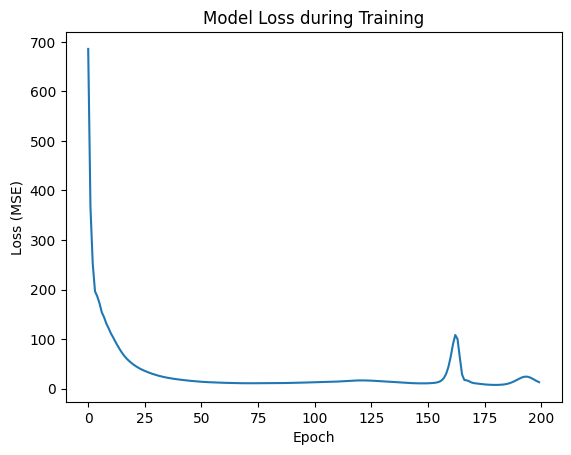

/tmp/ipython-input-3511089894.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


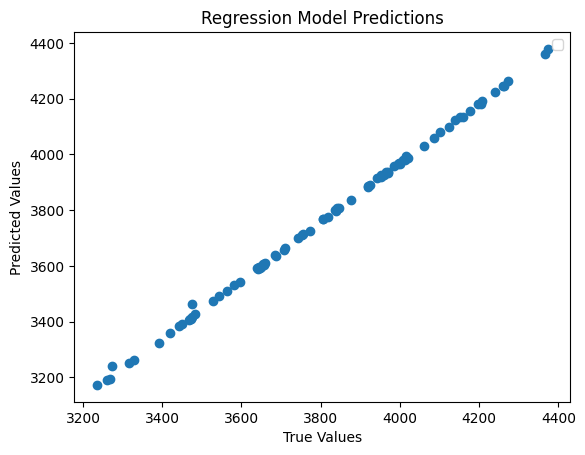

In [48]:
plt.plot(history.history['loss'])
plt.title('Model Loss during Training')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.show()

plt.scatter(y_test, y_pred)
#lt.plot(X, model.predict(X), color='red', label='Model Predictions')
plt.title('Regression Model Predictions')
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.show()